In [1]:
import  numpy as np
import pandas as pd
import scipy
from scipy import stats
from collections import Counter
from scipy.stats import binom
from scipy.stats import poisson
from scipy.stats import norm
from scipy.stats import t,expon
from collections import Counter
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import pylab
from pylab import legend
from pylab import plot, show, title, xlabel, ylabel

In [50]:
df= pd.read_excel("CDAC_DataBook.xlsx",sheet_name="ERPData")

In [5]:
grp1=df.groupby("MaterialID")

In [6]:
df1=grp1.Quantity.agg("sum")

<Axes: xlabel='MaterialID'>

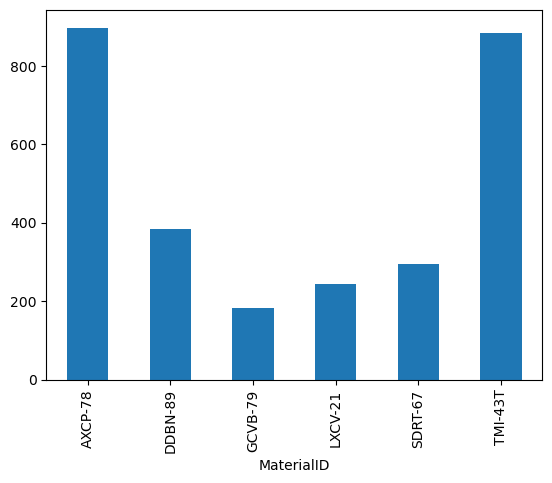

In [7]:
df1.plot(kind="bar")

In [8]:
df2=pd.crosstab(df.MaterialID,df.Location)

<Axes: xlabel='MaterialID'>

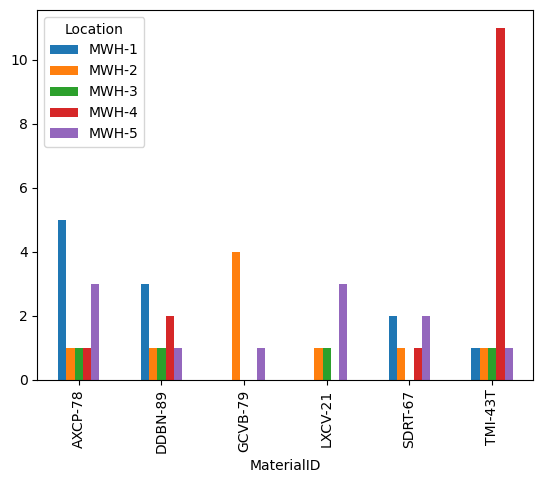

In [9]:
df2.plot(kind="bar")

In [10]:
df3=pd.crosstab(df.MaterialID,df.Location,values=df.Quantity,aggfunc="sum")

<Axes: xlabel='MaterialID'>

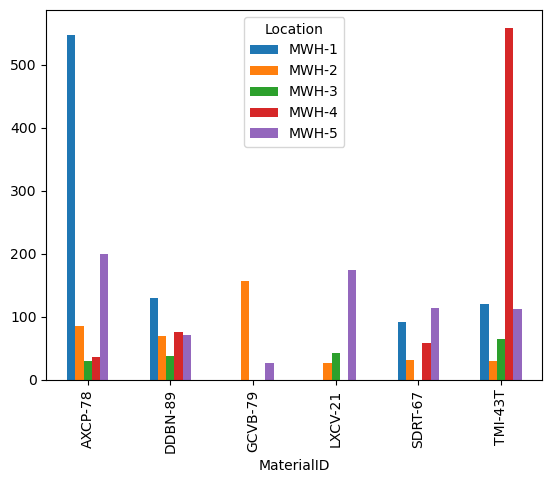

In [11]:
df3.plot(kind="bar")

In [12]:
df4=df.pivot_table(values="Quantity",index="MaterialID",columns="Location",aggfunc="sum")

<Axes: xlabel='MaterialID'>

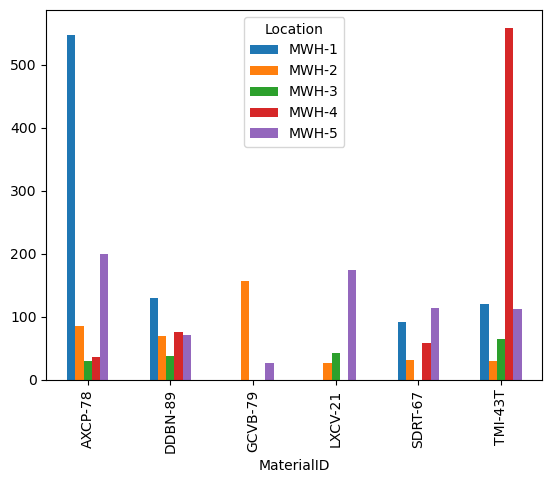

In [13]:
df4.plot(kind="bar")

<Axes: xlabel='MaterialID', ylabel='Quantity'>

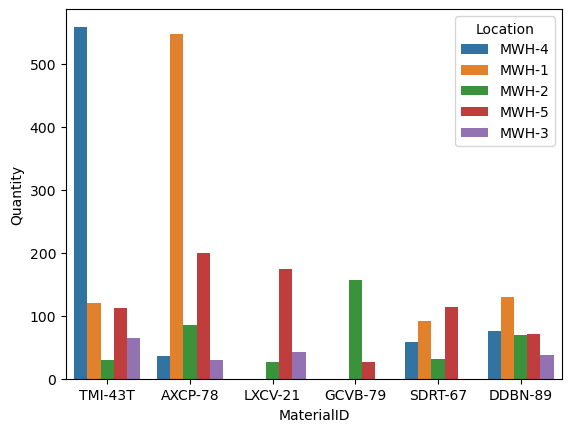

In [52]:
#seaborn
sns.barplot(x="MaterialID",y="Quantity",hue="Location",data=df,errorbar=None,estimator=np.sum)

{'whiskers': [<matplotlib.lines.Line2D at 0x1e10e8bac10>,
 'caps': [<matplotlib.lines.Line2D at 0x1e10e8bae90>,
 'boxes': [<matplotlib.lines.Line2D at 0x1e10e8baad0>,
 'medians': [<matplotlib.lines.Line2D at 0x1e10e8bb110>,
 'fliers': [<matplotlib.lines.Line2D at 0x1e10e8bb250>,
 'means': []}

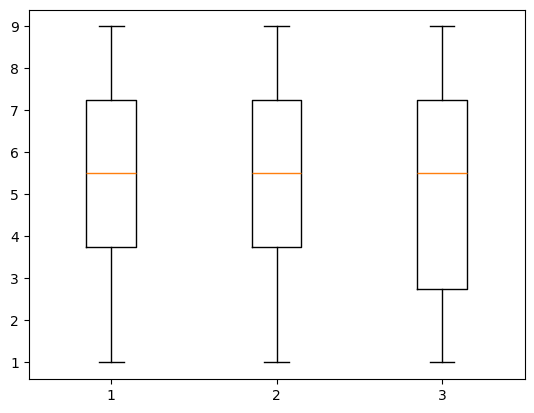

In [15]:
x1=[5,9,8,7,6,2,4,1,3,5,9,6,2,5,8,7]
x2=[2,5,6,9,8,7,4,6,2,3,1,4,5,6,8,9]
x3=[1,2,5,6,9,8,7,8,7,8,9,6,6,3,2,5,5,2,2,3]
plt.boxplot([x1,x2,x3])

<Axes: >

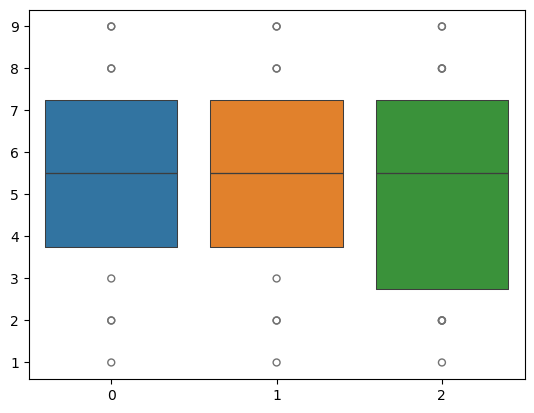

In [54]:
sns.boxenplot([x1,x2,x3])

In [55]:
df= pd.read_excel("CDAC_DataBook.xlsx",sheet_name="faithful")

In [21]:
df.head()

,eruptions,waiting
0,3.600,79
1,1.800,54
2,3.333,74
3,2.283,62
4,4.533,85


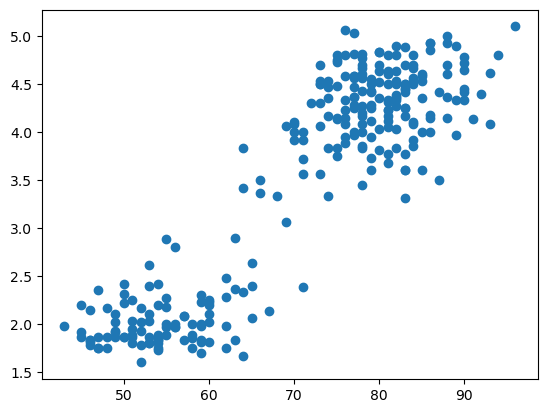

In [24]:
plt.scatter(df.waiting,df.eruptions) #Scatter Plot

(array([ 63.,  41.,  61., 107.]),
 array([1.5, 2.1, 3.5, 4.2, 5.2]),
 <BarContainer object of 4 artists>)

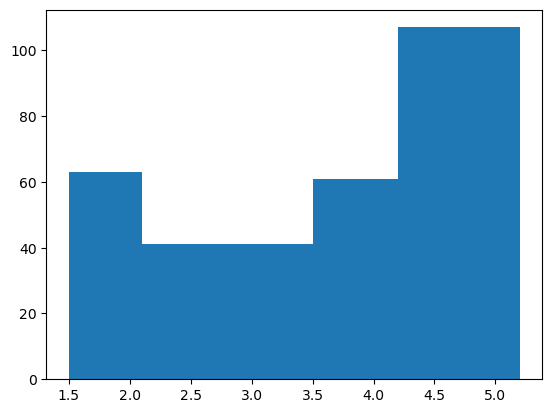

In [29]:
cats=[1.5,2.1,3.5,4.2,5.2]
plt.hist(df.eruptions,cats) # 1d Histogram   (Continious)

(array([45., 36., 13.,  3.,  4., 12., 29., 52., 54., 24.]),
 array([1.6 , 1.95, 2.3 , 2.65, 3.  , 3.35, 3.7 , 4.05, 4.4 , 4.75, 5.1 ]),
 <BarContainer object of 10 artists>)

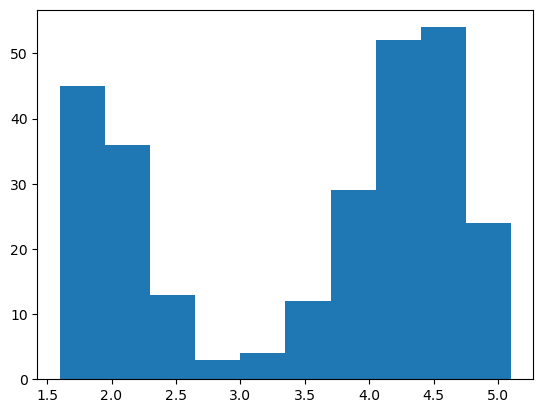

In [30]:
plt.hist(df.eruptions)

(array([[11., 15., 12.,  7.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 4.,  9., 11., 10.,  2.,  0.,  0.,  0.,  0.,  0.],
        [ 1.,  4.,  1.,  4.,  2.,  1.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  2.,  1.,  0.,  0.,  0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.,  2.,  1.,  0.,  1.,  0.,  0.],
        [ 0.,  0.,  0.,  1.,  2.,  2.,  2.,  4.,  1.,  0.],
        [ 0.,  0.,  0.,  1.,  0.,  6., 13.,  7.,  2.,  0.],
        [ 0.,  0.,  0.,  0.,  1.,  7., 18., 18.,  6.,  2.],
        [ 0.,  0.,  0.,  0.,  0.,  6., 19., 20.,  7.,  2.],
        [ 0.,  0.,  0.,  0.,  0.,  0., 10.,  5.,  7.,  2.]]),
 array([1.6 , 1.95, 2.3 , 2.65, 3.  , 3.35, 3.7 , 4.05, 4.4 , 4.75, 5.1 ]),
 array([43. , 48.3, 53.6, 58.9, 64.2, 69.5, 74.8, 80.1, 85.4, 90.7, 96. ]),
 <matplotlib.collections.QuadMesh at 0x1e102032510>)

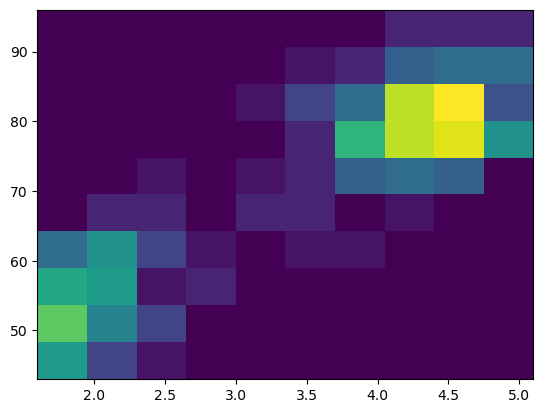

In [26]:
plt.hist2d(df.eruptions,df.waiting) #2d Histogram

In [31]:
df1=df.iloc[np.where(df.eruptions<=3.6)]
df2=df.iloc[np.where(df.eruptions>3.6)]

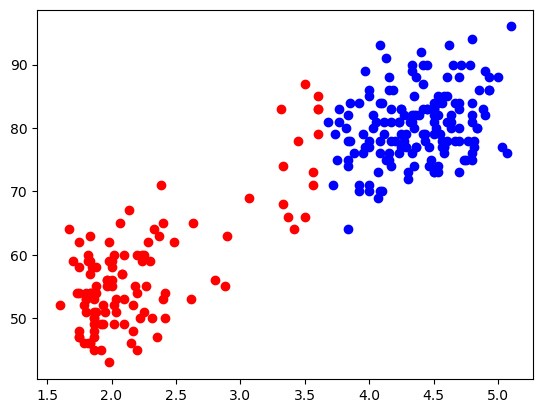

In [33]:
plt.scatter(df1.eruptions,df1.waiting,c='red')          #Grouped Scatter Plot
plt.scatter(df2.eruptions,df2.waiting,c='blue')

<Axes: xlabel='eruptions', ylabel='waiting'>

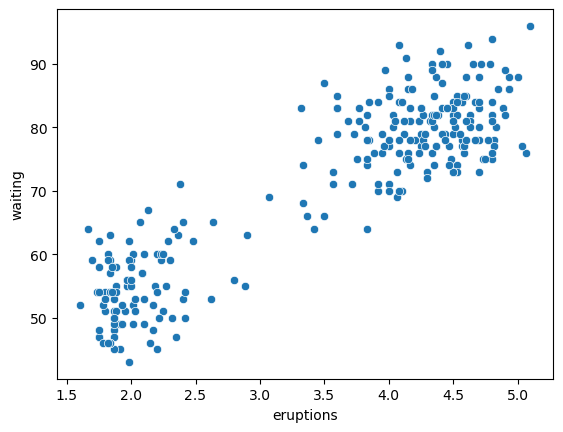

In [60]:
sns.scatterplot(x=df.eruptions,y=df.waiting)

<Axes: xlabel='eruptions', ylabel='Count'>

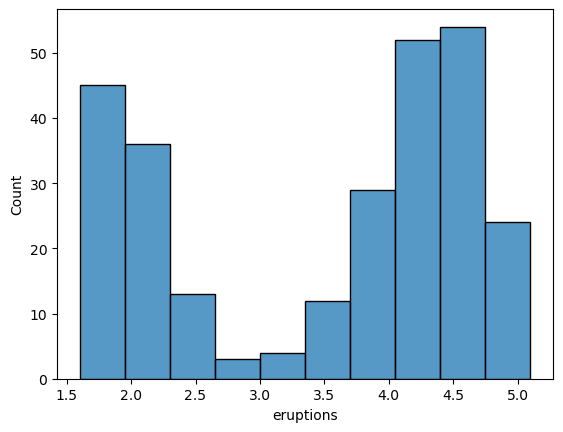

In [61]:
sns.histplot(df.eruptions)

In [63]:
grp1=np.random.normal(loc=10,scale=2,size=100)
grp2=np.random.normal(loc=15,scale=2.5,size=100)
bins=np.linspace(5,20,15)

(array([ 0.,  0.,  0.,  0.,  4.,  6., 10.,  7., 17., 14., 18., 14.,  4.,
         4.]),
 array([ 5.        ,  6.07142857,  7.14285714,  8.21428571,  9.28571429,
        10.35714286, 11.42857143, 12.5       , 13.57142857, 14.64285714,
        15.71428571, 16.78571429, 17.85714286, 18.92857143, 20.        ]),
 <BarContainer object of 14 artists>)

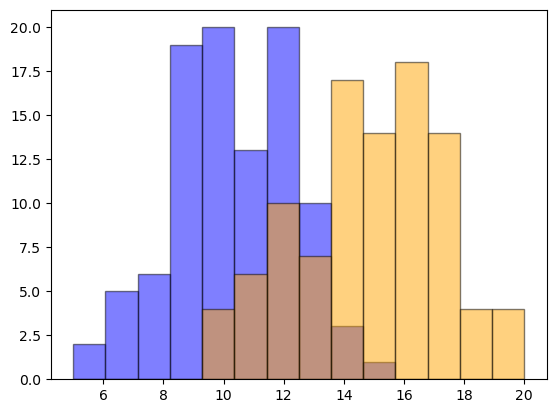

In [67]:
plt.hist(grp1,bins=bins,alpha=0.5,label="Volcano A",color="Blue",edgecolor="Black")
plt.hist(grp2,bins=bins,alpha=0.5,label="Volcano B",color="Orange",edgecolor="Black")

In [35]:
df=sns.load_dataset("titanic")

In [36]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [38]:
np.unique(df.pclass)

array([1, 2, 3])

In [39]:
class_count=df["pclass"].value_counts()

<BarContainer object of 3 artists>

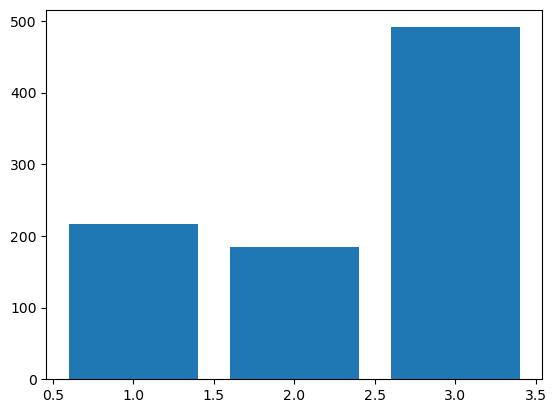

In [40]:
plt.bar(class_count.index,class_count.values)

<Axes: xlabel='class', ylabel='count'>

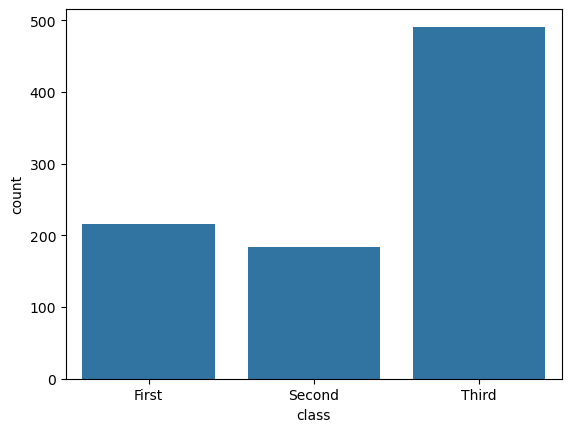

In [43]:
sns.countplot(x='class',data=df) #seaborn grpah

<Axes: xlabel='class', ylabel='fare'>

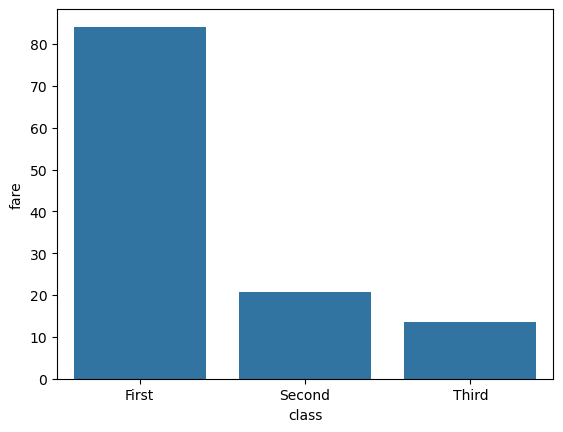

In [49]:
sns.barplot(x="class",y="fare",data=df,errorbar=None)

In [68]:
df=pd.read_excel("ManHours.xlsx")

In [69]:
df.head()

,Name,Client,Hours,Grade,Team
0,A,CDAC,3,A,2
1,B,CDAC,4,A,2
2,A,Infy,2,B,1
3,C,Infy,4,C,3
4,A,CDAC,3,A,2


In [73]:
0.2*360

72.0

In [ ]:
pl